# Preamble

In [1]:
try:
    print(f"Spark version {sc.version}")
except:
    %run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [13]:
clean_spark()

CLEANING SPARK INSTANCE...


In [1]:
import os
import logging
from datetime import datetime
import time
import re

import ipaddress
import pytricia
import publicsuffixlist as psl

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
#import plotly.express as px

import pyspark.sql.types as pst
import pyspark.sql.functions as psf
from typing import Iterator
from pyspark.sql.window import Window

# local imports
from census_helper import download_date

In [3]:
#sc.setCheckpointDir("checkpoint/")

In [4]:
# Create logger
logger = logging.getLogger("anycast_services")
logger.setLevel(logging.INFO)

# Prevent duplicate logs if logger already has handlers
if not logger.handlers:
    # Create file handler
    file_handler = logging.FileHandler("logs.log", encoding='utf-8')
    file_handler.setLevel(logging.INFO)
    
    # Create formatter
    formatter = logging.Formatter(
        fmt='%(asctime)s %(levelname)-8s %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    
    # Add formatter to handler
    file_handler.setFormatter(formatter)
    
    # Add handler to logger
    logger.addHandler(file_handler)
else:
    print("logger already exist!")

# Optionally, prevent propagation to root logger to avoid duplicates
logger.propagate = False

In [5]:
## Create PublicSuffixList
# NOTE: Update PSL.dat if older than a day!
if time.time() - os.path.getctime("/opt/conda/lib/python3.10/site-packages/publicsuffixlist/public_suffix_list.dat") > (24*3600):
    print("Updating PSL file.")
    !python -m publicsuffixlist.update
else:
    !python -m publicsuffixlist.test 

Updating PSL file.
This is a script to download the latest PSL file.
Do not run this repeatedly more than once per day.
PSL updated
last-modified: Tue, 17 Mar 2026 08:50:56 GMT


# Helper functions and definitions

In [6]:
# Base prefix of fDNS warehouse data
INFRA_FDNS_WAREHOUSE_BASE = "s3a://openintel/catalog/warehouse/fdns/data/"
FDNS_WAREHOUSE_BASE = "s3a://openintel/category=fdns/type=warehouse"

infra_sources = [
    "infra%3Ans"
    #"infra%3Amx",
    #"infra%3Atlsa",
]

sources = [
    "com", "net", "org", 
    "czds",  # new gTLDs
    # raffaele's paper
    #"at", "ca", "dk", "fi", "nl", "nu", "se",
    #"umbrella",

    # other gtlds
    #"info", "mobi", "name", "asia", "biz", "imp"  # not available
    
    #"root", 
    #"gov",
    #"radar", "majestic", "crux", "tranco"  # lists
    #"us", "gt", "na", "ee", "co", "ch", "li", "sk", "fr", "cl", "su"
    #"opencc", "closedcc",

    #"ip6-chli",
    #"ct-logs", "fed.us", "bis", "aero",
    #"alexa",  # not available for the given date
    # "ru", "xn--p1ai",  # ignore
]

In [10]:
psl_obj = psl.PublicSuffixList()
tld_regex_dict = {}
for tld in psl.PublicSuffixList()._publicsuffix:
    # https://github.com/publicsuffix/list/wiki/Format
    tld_escaped = tld.replace("*.", "[a-zA-Z]*.?").replace("!", "")  # ! is a prefference over the generic rule
    _domain_pattern = fr'([^.]+)[.]({tld_escaped}).?$'
    tld_clean = tld.replace("*.", "").replace("!", "")
    tld_regex_dict[tld_clean] = re.compile(_domain_pattern, re.IGNORECASE)


def extract_apex_domain_logic(x: str, psl_obj, tld_regex_dict):
    # x: query_name
    if x is None:
        return None

    # invalid case:query:_dmarc.siter.io., txt_text contains ma""ilinblue.com!10m
    #                                                           x
    # invalid case:query:_dmarc.fnspfdr.sk, txt_text contains rua=mailto:dmarc@hostcreators.sk ruf=mailto:dmarc@hostcreators.sk; resulting in a rua_domain:hostcreators.sk hostcreators.sk
    #                                                                                         x
    if '"' in x or ' ' in x:
        return None

    tld = psl_obj.publicsuffix(x)  # get the com.br from a.example.com.br
    if tld is None:
        return None  # invalid suffix

    # to avoid cases such as v.ua
    tld_escaped = tld.replace("*.", "")
    if tld_escaped == x.rstrip("."):
        return tld_escaped

    x_escaped = x
    # rfc7489#section-6.2
    #   For example, the URI "mailto:reports@example.com!50m" would request
    #   that a report be sent via email to "reports@example.com" so long as
    #   the report payload does not exceed 50 megabytes.
    if "!" in tld_escaped:
        tld_escaped = ''.join(tld_escaped.split("!")[0])
        x_escaped = ''.join(x.split("!")[0])

    try:
        prog = tld_regex_dict[tld_escaped]
    except KeyError:
        if "." in tld:
            catch_all_tld = tld.split(".")[-1]
            prog = tld_regex_dict[catch_all_tld]
        else:
            return None

    m = prog.search(x_escaped)
    if m:
        return f"{m.group(1).strip()}.{m.group(2).strip()}"
    return None


broadcast_psl_obj = spark.sparkContext.broadcast(psl_obj)
broadcast_tld_regex = spark.sparkContext.broadcast(tld_regex_dict)

@psf.pandas_udf(pst.StringType())
def extract_apex_domain(query_name: pd.Series) -> pd.Series:
    _psl_obj = broadcast_psl_obj.value
    _tld_regex_dict = broadcast_tld_regex.value
    return query_name.apply(lambda x: extract_apex_domain_logic(x, _psl_obj, _tld_regex_dict))


def extract_tld_logic(x, psl_obj):
    """
    Extract country code TLD from a domain name.
    
    Args:
        x: Domain name string
        psl_obj: PublicSuffixList object for extracting TLDs

    Returns:
        Extracted country code TLD or government TLD
    """
    if x is None:
        return None
    tld = psl_obj.publicsuffix(x)
    return tld


@psf.pandas_udf(pst.StringType())
def extract_tld(query_name: pd.Series) -> pd.Series:
    # extract the .br from example.com.br because we don't need a second level tld to identify a domain from a country
    _psl_obj = broadcast_psl_obj.value
    return query_name.apply(lambda x: extract_tld_logic(x, _psl_obj))

In [8]:
snapshot = datetime(2026, 2, 18)

# to analyze address agility
timestamps = [
    datetime(2026, 2, 4),
    datetime(2026, 2, 11),
    datetime(2026, 2, 18)
]

Nr TLDs in czds

In [9]:
spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source=czds/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
).select("query_name").withColumn(
    "tld", extract_tld(psf.col("query_name"))
).select("tld").distinct().count()

1519

In [12]:
spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source=czds/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
).select("query_name").withColumn(
    "tld", extract_tld(psf.col("query_name"))
).select("query_name", "tld").distinct().show(truncate=False)

+-----------------------------------------+--------+
|query_name                               |tld     |
+-----------------------------------------+--------+
|esn.one.                                 |one     |
|www.esds.one.                            |one     |
|ess.zone.                                |zone    |
|www.esthe.care.                          |care    |
|www.ers.care.                            |care    |
|erasmus.care.                            |care    |
|www.erics.software.                      |software|
|ericeli28.store.                         |store   |
|_dmarc.ertepe3-uno89.store.              |store   |
|essenza-profumeria.store.                |store   |
|estrelaguia.store.                       |store   |
|www.estyma.store.                        |store   |
|www.estera.store.                        |store   |
|www.estafetta.store.                     |store   |
|123-nonexistant-dnsjedi-456.eswllc.store.|store   |
|esincloud.store.                         |sto

# Web

In [9]:
_anycast_pdf = download_date(snapshot, "v4")
anycast_pdf = _anycast_pdf[_anycast_pdf['GCD_ICMPv4'] > 1].copy() # filter on GCD-confirmed (high accuracy)

# locations of anycast sites
location_struct = pst.StructType([
    pst.StructField("city", pst.StringType(), True),
    pst.StructField("code_country", pst.StringType(), True), 
    pst.StructField("id", pst.StringType(), True),
    pst.StructField("latitude", pst.DoubleType(), True), 
    pst.StructField("longitude", pst.DoubleType(), True)
])

# schema
full_schema = pst.StructType([
    pst.StructField("prefix", pst.StringType(), True),
    pst.StructField("AB_ICMPv4", pst.LongType(), True),
    pst.StructField("AB_TCPv4", pst.LongType(), True),
    pst.StructField("AB_DNSv4", pst.LongType(), True),
    pst.StructField("GCD_ICMPv4", pst.LongType(), True),
    pst.StructField("GCD_TCPv4", pst.LongType(), True),
    pst.StructField("partial", pst.BooleanType(), True),
    pst.StructField("backing_prefix", pst.StringType(), True),
    pst.StructField("ASN", pst.StringType(), True),
    # list of location structs
    pst.StructField("locations", pst.ArrayType(location_struct), True) 
])

anycast_prefixes_df = spark.createDataFrame(anycast_pdf, schema=full_schema)

In [23]:
# web on anycast...
# IPv4
for source in sources:
    t1 = time.time()
    try:
        df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}")
    except:
        logger.info(f"{source} not available")
        continue

    df.select("query_type", "ip4_address", "query_name").filter(
        (psf.col("query_type") == "A")
        & (psf.col("ip4_address").isNotNull())
    ).withColumn(
        "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
    ).join(
        psf.broadcast(anycast_prefixes_df.select("prefix", "ASN")),
        on="prefix",
        how="left"
    ).withColumn(
        "type", psf.when(psf.col("ASN").isNull(), "unicast").otherwise("anycast")
    ).select(psf.col("ip4_address").alias("ip"), "query_name", "type").filter(
        (psf.col("query_name").isNotNull())
        & (psf.col("ip").isNotNull())
    ).distinct().write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/web_analysis/protocol=v4/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

    t2 = time.time()
    print(source, "took", round(t2-t1, 1), "seconds to process")
    logger.info(f"{source} took {round(t2-t1, 1)}s to process")

com took 488.2 seconds to process
net took 46.2 seconds to process
org took 46.0 seconds to process
czds took 129.4 seconds to process


In [25]:
web_on_anycast_df = spark.read.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/web_analysis/protocol=v4/source=*/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

In [26]:
grouped_domains_df = web_on_anycast_df.filter(psf.col("ip").isNotNull()).groupBy("query_name").agg(
    psf.collect_set("type").alias("types_set")
)

classified_df = grouped_domains_df.withColumn(
    "domain_type",
    psf.when(psf.size("types_set") > 1, "mix")
    .otherwise(psf.col("types_set")[0])
)

summary_df = classified_df.groupBy("domain_type").count().withColumn("percentage", psf.round(psf.col("count") / psf.sum("count").over(Window.partitionBy()) * 100, 2))
summary_df.show()
summary_df.select(psf.sum("count")).show()

+-----------+---------+----------+
|domain_type|    count|percentage|
+-----------+---------+----------+
|        mix|   668575|      0.18|
|    anycast|197915807|     52.57|
|    unicast|177882262|     47.25|
+-----------+---------+----------+

+----------+
|sum(count)|
+----------+
| 376466644|
+----------+



In [14]:
_anycast6_pdf = download_date(snapshot, "v6")
anycast6_pdf = _anycast6_pdf[_anycast6_pdf['GCD_ICMPv6'] > 1].copy() # filter on GCD-confirmed (high accuracy)

# schema
full_schema6 = pst.StructType([
    pst.StructField("prefix", pst.StringType(), True),
    pst.StructField("AB_ICMPv6", pst.LongType(), True),
    pst.StructField("AB_TCPv6", pst.LongType(), True),
    pst.StructField("AB_DNSv6", pst.LongType(), True),
    pst.StructField("GCD_ICMPv6", pst.LongType(), True),
    pst.StructField("GCD_TCPv6", pst.LongType(), True),
    pst.StructField("backing_prefix", pst.StringType(), True),
    pst.StructField("ASN", pst.StringType(), True),
    # list of location structs
    pst.StructField("locations", pst.ArrayType(location_struct), True) 
])

anycast_prefixes6_df = spark.createDataFrame(anycast6_pdf, schema=full_schema6)

In [24]:
# web on anycast...
# IPv6
anycast_ipv6_prefixes = anycast_prefixes6_df.select("prefix").rdd.flatMap(lambda x: x).collect()
bc_prefixes_v6 = spark.sparkContext.broadcast(anycast_ipv6_prefixes)

# 2. Define the highly-efficient Iterator Pandas UDF
@psf.pandas_udf(pst.BooleanType())
def is_anycast_v6_udf(ipv6_iter: Iterator[pd.Series]) -> Iterator[pd.Series]:    
    # Initialize the tree once per Spark task
    pyt = pytricia.PyTricia(128)
    for prefix in bc_prefixes_v6.value:
        pyt.insert(prefix, True)
        
    # Process batches
    for ipv6_series in ipv6_iter:
        # A quick helper function to safely check the IP and handle malformed strings
        def check_ip(ip):
            if not ip: return False
            try:
                return ip in pyt
            except:
                return False # Failsafe if PyTricia encounters a garbage string
                
        yield ipv6_series.apply(check_ip)


for source in sources:
    t1 = time.time()
    try:
        df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}")
    except:
        logger.info(f"{source} not available")
        continue

    df.select("query_type", "ip6_address", "query_name").filter(
        (psf.col("query_type") == "AAAA")
        & (psf.col("ip6_address").isNotNull())
    ).withColumn(
        # Apply the PyTricia UDF instead of a join
        "is_anycast", is_anycast_v6_udf(psf.col("ip6_address"))
    ).withColumn(
        "type", psf.when(psf.col("is_anycast") == True, psf.lit("anycast")).otherwise(psf.lit("unicast"))
    ).select(psf.col("ip6_address").alias("ip6"), "query_name", "type").filter(
        (psf.col("query_name").isNotNull())
        & (psf.col("ip6").isNotNull())
    ).distinct(
    ).write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/web_analysis/protocol=v6/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

    t2 = time.time()
    print(source, "took", round(t2-t1, 1), "seconds to process")
    logger.info(f"{source} took {round(t2-t1, 1)}s to process")

com took 249.2 seconds to process
net took 32.0 seconds to process
org took 30.2 seconds to process
czds took 72.5 seconds to process


In [27]:
web_on_anycast6_df = spark.read.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/web_analysis/protocol=v6/source=*/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

In [29]:
grouped_domains6_df = web_on_anycast6_df.filter(psf.col("ip6").isNotNull()).groupBy("query_name").agg(
    psf.collect_set("type").alias("types_set")
)

classified6_df = grouped_domains6_df.withColumn(
    "domain_type",
    psf.when(psf.size("types_set") > 1, "mix")
    .otherwise(psf.col("types_set")[0])
)

summary6_df = classified6_df.groupBy("domain_type").count().withColumn("percentage", psf.round(psf.col("count") / psf.sum("count").over(Window.partitionBy()) * 100, 2))
summary6_df.show()
summary6_df.select(psf.sum("count")).show()

+-----------+--------+----------+
|domain_type|   count|percentage|
+-----------+--------+----------+
|        mix|  437976|      0.57|
|    anycast|42772618|     56.09|
|    unicast|33043261|     43.33|
+-----------+--------+----------+

+----------+
|sum(count)|
+----------+
|  76253855|
+----------+



In [25]:
df.count()

246428142

In [26]:
df.select("ip", "hostname").distinct().count()

223211031

In [27]:
df.select("ip", "hostname").distinct().write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/name_analysis/source=all/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

# NS

In [9]:
_anycast_pdf = download_date(snapshot, "v4")
anycast_pdf = _anycast_pdf[_anycast_pdf['GCD_ICMPv4'] > 1].copy() # filter on GCD-confirmed (high accuracy)

# locations of anycast sites
location_struct = pst.StructType([
    pst.StructField("city", pst.StringType(), True),
    pst.StructField("code_country", pst.StringType(), True), 
    pst.StructField("id", pst.StringType(), True),
    pst.StructField("latitude", pst.DoubleType(), True), 
    pst.StructField("longitude", pst.DoubleType(), True)
])

# schema
full_schema = pst.StructType([
    pst.StructField("prefix", pst.StringType(), True),
    pst.StructField("AB_ICMPv4", pst.LongType(), True),
    pst.StructField("AB_TCPv4", pst.LongType(), True),
    pst.StructField("AB_DNSv4", pst.LongType(), True),
    pst.StructField("GCD_ICMPv4", pst.LongType(), True),
    pst.StructField("GCD_TCPv4", pst.LongType(), True),
    pst.StructField("partial", pst.BooleanType(), True),
    pst.StructField("backing_prefix", pst.StringType(), True),
    pst.StructField("ASN", pst.StringType(), True),
    # list of location structs
    pst.StructField("locations", pst.ArrayType(location_struct), True) 
])

anycast_prefixes_df = spark.createDataFrame(anycast_pdf, schema=full_schema)

## nameservers

unicast: no IP address of the domain name is on anycast prefix

anycast: all IP addresses associated with the given domain name is anycasted

mixed: mixed of above

In [20]:
spark.read.parquet(f"{INFRA_FDNS_WAREHOUSE_BASE}/source=infra%3Ans/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}").select("query_name").distinct().count()

2852563

In [24]:
spark.read.parquet(f"{INFRA_FDNS_WAREHOUSE_BASE}/source=infra%3Ans/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}"
).select("ip4_address").filter(psf.col("ip4_address").isNotNull()).distinct().count()

739493

In [10]:
spark.read.parquet(f"{INFRA_FDNS_WAREHOUSE_BASE}/source=infra%3Ans/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}"
).select("ip4_address").filter(psf.col("ip4_address").isNotNull()).distinct(
).withColumn(
    "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
).join(
    anycast_prefixes_df.select("prefix", "GCD_ICMPv4"),
    on=["prefix"],
    how="left",
).withColumn(
    "type", psf.when(psf.col("GCD_ICMPv4").isNull(), "unicast").otherwise("anycast")
).groupBy("type").agg(
    psf.countDistinct("ip4_address").alias("count")
).show()

+-------+------+
|   type| count|
+-------+------+
|anycast| 22685|
|unicast|716808|
+-------+------+



In [27]:
#ns_anycast_addresses_df = 
spark.read.parquet(f"{INFRA_FDNS_WAREHOUSE_BASE}/source=infra%3Ans/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}"
).select("ip4_address").filter(psf.col("ip4_address").isNotNull()).distinct(
).withColumn(
    "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
).join(
    anycast_prefixes_df.select("prefix", "GCD_ICMPv4"),
    on=["prefix"],
    how="left",
).withColumn(
    "type", psf.when(psf.col("GCD_ICMPv4").isNull(), "unicast").otherwise("anycast")
).select("ip4_address", "type"
).write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_anycast_ip_addresses/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}/ips")

#ns_anycast_addresses_df = ns_anycast_addresses_df.repartition(24, "ip4_address")

In [28]:
spark.read.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_anycast_ip_addresses/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}/ips"
).filter(
    psf.col("type") == "anycast"
).filter(
    psf.col("ip4_address").isNotNull()
).select("ip4_address").distinct().coalesce(1
).write.csv(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_anycast_ip_addresses/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}/ips_uniq", header=False)

In [23]:
# OLD
if False:
    ns_anycast_df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source=infra%3Ans/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}"
    ).select("query_name", "ip4_address"
    ).withColumn(
        "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
    ).join(
        anycast_prefixes_df.select("prefix", "GCD_ICMPv4"),
        on=["prefix"],
        how="left",
    ).withColumn(
        "type", psf.when(psf.col("GCD_ICMPv4").isNull(), "unicast").otherwise("anycast")
    ).withColumn(
        "ns_apex_address", extract_apex_domain(psf.col("query_name"))  # this is the nameserver domain name
    ).select("prefix", psf.col("query_name").alias("ns_address"), "ns_apex_address", "type")
    
    try:
        ns_anycast_df.unpersist()
    except:
        pass
    
    ns_anycast_df.persist()
    
    ns_anycast_df.count()

3870690

In [24]:
# OLD
if False:
    ns_anycast_df.distinct().groupBy("ns_apex_address").agg(
        psf.sort_array(psf.collect_set("type")).alias("types")
    ).groupBy("types").count().show()

+------------------+-------+
|             types|  count|
+------------------+-------+
|[anycast, unicast]|  24527|
|         [anycast]|  21785|
|         [unicast]|1195431|
+------------------+-------+



Raffaele's paper table IV:  

#NS(IP)
         | anycast | unicast | mixed | total  
in 2017  | 10700   | 899028  | N/A   | 909728  
in 2021  | 18179   | 756459  | N/A   | 774638  

   
in 2026  | 22685   | 716808 | N/A    | 739493

Exporting to objstore... do not run this again...

In [10]:
ns_anycast_df = spark.read.parquet(f"{INFRA_FDNS_WAREHOUSE_BASE}/source=infra%3Ans/date={snapshot.year}-{snapshot.month:02d}-{snapshot.day:02d}"
).select("query_name", "ip4_address"
).withColumn(
    "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
).join(
    anycast_prefixes_df.select("prefix", "GCD_ICMPv4"),
    on=["prefix"],
    how="left",
).withColumn(
    "type", psf.when(psf.col("GCD_ICMPv4").isNull(), "unicast").otherwise("anycast")
).select("prefix", psf.col("query_name").alias("ns_address"), psf.col("ip4_address").alias("ns_ip4_address"), "type")

In [14]:
for source in sources:  #["info", "mobi", "name", "asia", "biz", "imp"]:
    t1 = time.time()
    try:
        df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
        ).select("query_type", "query_name", "ns_address").filter(
            (psf.col("query_type") == "NS")
            & (psf.col("ns_address").isNotNull())
        ).select("query_name", "ns_address")
        #df.persist()
        
    except:
        logger.info(f"{source} not available")
        print(f"{source} not available")
        continue

    df = df.repartition(24, "ns_address")
    ns_anycast_df = ns_anycast_df.repartition(24, "ns_address")

    df.join(
        ns_anycast_df, on="ns_address", how="inner"
    ).select("query_name", "ns_address", "ns_ip4_address", "prefix", "type", 
    ).distinct(
    ).write.parquet(
        f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/"
    )

    t2 = time.time()
    print(f"{source} took {round(t2-t1, 1)}s to process")
    logger.info(f"{source} took {round(t2-t1, 1)}s to process")

#com took 2350.1s to process
#net took 1657.6s to process
#org took 1496.2s to process
#czds took 1395.5s to process
#at not available
#ca not available
#dk not available
#fi took 206.6s to process
#nl took 1266.6s to process
#nu took 61.8s to process
#se took 1217.7s to process
#umbrella took 30.0s to process

ch took 82.4s to process
se took 78.4s to process


In [11]:
domains_on_ns_df = spark.read.option("basePath", "s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/"
).parquet(
    f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/source=*/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/"
)

In [16]:
domains_on_ns_df.printSchema()

root
 |-- query_name: string (nullable = true)
 |-- ns_address: string (nullable = true)
 |-- ns_ip4_address: string (nullable = true)
 |-- prefix: string (nullable = true)
 |-- type: string (nullable = true)
 |-- source: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [18]:
domains_on_ns_df.select("year", "month", "day").distinct().show()

+----+-----+---+
|year|month|day|
+----+-----+---+
|2026|    2| 18|
+----+-----+---+



In [19]:
domains_on_ns_df.filter(
    (psf.col("source").isin(sources))
    & (psf.col("year") == snapshot.year)
    & (psf.col("month") == snapshot.month)
    & (psf.col("day") == snapshot.day)
).select("source").distinct().show()

+------+
|source|
+------+
|   com|
|  czds|
|   net|
|   org|
+------+



In [20]:
# THIS WORKS!
grouped_domains_df = domains_on_ns_df.filter(
    (psf.col("source").isin(sources))
    & (psf.col("year") == snapshot.year)
    & (psf.col("month") == snapshot.month)
    & (psf.col("day") == snapshot.day)
).filter(psf.col("ns_ip4_address").isNotNull()).groupBy("query_name").agg(
    psf.collect_set("type").alias("types_set")
)

classified_df = grouped_domains_df.withColumn(
    "domain_type",
    psf.when(psf.size("types_set") > 1, "mix")
    .otherwise(psf.col("types_set")[0])
)

# 3. Group by the new classification and count the totals
summary_df = classified_df.groupBy("domain_type").count()
summary_df.show()

+-----------+---------+
|domain_type|    count|
+-----------+---------+
|        mix|  7401561|
|    anycast|148426104|
|    unicast| 48261216|
+-----------+---------+



In [23]:
# using open ccdls:
grouped_domains_df = domains_on_ns_df.filter(
    (psf.col("source").isin(["ch", "se"]))
    & (psf.col("year") == snapshot.year)
    & (psf.col("month") == snapshot.month)
    & (psf.col("day") == snapshot.day)
).filter(psf.col("ns_ip4_address").isNotNull()).groupBy("query_name").agg(
    psf.collect_set("type").alias("types_set")
)

classified_df = grouped_domains_df.withColumn(
    "domain_type",
    psf.when(psf.size("types_set") > 1, "mix")
    .otherwise(psf.col("types_set")[0])
)

# 3. Group by the new classification and count the totals
summary_df = classified_df.groupBy("domain_type").count().withColumn("percentage", psf.round(psf.col("count") / psf.sum("count").over(Window.partitionBy()) * 100, 2))
summary_df.show()
summary_df.select(psf.sum("count")).show()
cctld_summary_pdf = summary_df.toPandas()

+-----------+-------+----------+
|domain_type|  count|percentage|
+-----------+-------+----------+
|        mix|  76813|      2.06|
|    anycast|1537937|     41.32|
|    unicast|2107376|     56.62|
+-----------+-------+----------+

+----------+
|sum(count)|
+----------+
|   3722126|
+----------+



In [31]:
# differences

# gtld_summary is just simply a copy from above table...
data = {
    "domain_type": ["mix", "anycast", "unicast"],
    "count_orig": [7401561, 148426104, 48261216]
}
# Create the DataFrame
gtld_summary_pdf = pd.DataFrame(data)

cctld_summary_pdf.drop("percentage", axis='columns', inplace=True)
cctld_summary_pdf = cctld_summary_pdf.rename(columns={"count": "count_new"})

# 3. Merge the datasets together based on "domain_type"
df_combined = pd.merge(gtld_summary_pdf, cctld_summary_pdf, on="domain_type")

# 4. Add the counts together for the final combined count
df_combined["count_combined"] = df_combined["count_orig"] + df_combined["count_new"]

# ==========================================
# CALCULATION 1: Volume Totals
# ==========================================
total_orig = df_combined["count_orig"].sum()
total_new = df_combined["count_new"].sum()
total_combined = df_combined["count_combined"].sum()

print("--- VOLUME TOTALS ---")
print(f"Original Total: {total_orig:,}")
print(f"New Data Total: {total_new:,}")
print(f"Combined Total: {total_combined:,}")

# Calculate how much % the new data adds to the original
size_increase_pct = (total_new / total_orig) * 100
print(f"Data Growth: The new data is only {size_increase_pct:.2f}% the size of the original data.\n")

# ==========================================
# CALCULATION 2: Percentage Shifts
# ==========================================
# Calculate the percentage breakdown for the original data
df_combined["pct_orig"] = (df_combined["count_orig"] / total_orig) * 100

# Calculate the percentage breakdown for the combined data
df_combined["pct_combined"] = (df_combined["count_combined"] / total_combined) * 100

# Calculate the difference (shift)
df_combined["pct_shift"] = df_combined["pct_combined"] - df_combined["pct_orig"]

# Clean up the output to easily view the results
df_final_display = df_combined[["domain_type", "pct_orig", "pct_combined", "pct_shift"]].copy()

# Round everything to 2 decimal places for easy reading
df_final_display["pct_orig"] = df_final_display["pct_orig"].round(2)
df_final_display["pct_combined"] = df_final_display["pct_combined"].round(2)
df_final_display["pct_shift"] = df_final_display["pct_shift"].round(2)

print("--- DISTRIBUTION SHIFTS (%) ---")
print(df_final_display.to_string(index=False))

--- VOLUME TOTALS ---
Original Total: 204,088,881
New Data Total: 3,722,126
Combined Total: 207,811,007
Data Growth: The new data is only 1.82% the size of the original data.

--- DISTRIBUTION SHIFTS (%) ---
domain_type  pct_orig  pct_combined  pct_shift
        mix      3.63          3.60      -0.03
    anycast     72.73         72.16      -0.56
    unicast     23.65         24.24       0.59


In [13]:
# checking contributions of ASes
grouped_domains_df = domains_on_ns_df.filter(
    (psf.col("source").isin(sources))
    & (psf.col("year") == snapshot.year)
    & (psf.col("month") == snapshot.month)
    & (psf.col("day") == snapshot.day)
).filter(psf.col("ns_ip4_address").isNotNull()).join(
    anycast_prefixes_df.select("prefix", "ASN"),
    on="prefix",
    how="left"
).groupBy("query_name").agg(
    psf.collect_set("type").alias("types_set"),
    psf.collect_set("ASN").alias("ASes")
)

classified_df = grouped_domains_df.withColumn(
    "domain_type",
    psf.when(psf.size("types_set") > 1, "mix")
    .otherwise(psf.col("types_set")[0])
)

# 3. Group by the new classification and count the totals
summary_df = classified_df.groupBy("domain_type").count()
summary_df.show()

+-----------+---------+
|domain_type|    count|
+-----------+---------+
|        mix|  7401561|
|    anycast|148426104|
|    unicast| 48261216|
+-----------+---------+



In [19]:
classified_df.filter(
    psf.col("domain_type") == "anycast"
).select("query_name", psf.explode_outer("ASes").alias("ASN")).select("query_name", psf.explode(psf.split(psf.col("ASN"), "_")).alias("asn")
).groupBy("asn").agg(
    psf.countDistinct("query_name").alias("count")
).sort("count", ascending=False).show()

+------+--------+
|   asn|   count|
+------+--------+
| 44273|56861431|
| 13335|44569784|
| 15169|15667702|
| 12008|10294153|
|  8560| 6641917|
| 62597| 4639109|
| 16509| 3000730|
| 15418| 2775405|
| 63911| 2175881|
|  2635| 1268400|
|  1921| 1165052|
|207021| 1025224|
|209453|  587752|
| 51468|  584386|
|197495|  584385|
| 55195|  369751|
| 38719|  368820|
|394354|  363654|
| 16552|  262670|
|203391|  235649|
+------+--------+
only showing top 20 rows



In [9]:
domains_on_ns_df.groupBy("query_name").agg(
    psf.collect_list("ns_address").alias("name_servers"),
    psf.collect_list("ns_ip4_address").alias("name_server_addresses"),
    psf.collect_set("type").alias("types_set")
).filter(
    psf.size("types_set") > 1
).show(5, truncate=False)

+--------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------+------------------+
|query_name    |name_servers                                                                                                                                                                                                    |name_server_addresses                                                                        |types_set         |
+--------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------+---

In [12]:
domains_on_ns_df.show(10, truncate=False)

+---------------------------+-----------------------------+--------------+---------------+-------+
|query_name                 |ns_address                   |ns_ip4_address|prefix         |type   |
+---------------------------+-----------------------------+--------------+---------------+-------+
|reaktivierung-schweiss.com.|10726.dns3.managedns.org.    |172.233.81.45 |172.233.81.0/24|unicast|
|innodhruti.com.            |10726.dns3.managedns.org.    |172.233.81.45 |172.233.81.0/24|unicast|
|clouduslos.com.            |10932.dns1.managedns.org.    |138.68.134.109|138.68.134.0/24|unicast|
|skyusdns.com.              |10932.dns1.managedns.org.    |138.68.134.109|138.68.134.0/24|unicast|
|holidayvillagebd.com.      |1301.dns4.managedns.org.     |172.235.27.249|172.235.27.0/24|unicast|
|disl.com.                  |13381.venus.orderbox-dns.com.|162.251.82.120|162.251.82.0/24|anycast|
|disl.com.                  |13381.venus.orderbox-dns.com.|162.251.82.121|162.251.82.0/24|anycast|
|disl.com.

In [16]:
anycast_prefixes_df.filter(psf.col("prefix") == "108.162.194.0/24").show()

+----------------+---------+--------+--------+----------+---------+-------+----------------+-----+--------------------+
|          prefix|AB_ICMPv4|AB_TCPv4|AB_DNSv4|GCD_ICMPv4|GCD_TCPv4|partial|  backing_prefix|  ASN|           locations|
+----------------+---------+--------+--------+----------+---------+-------+----------------+-----+--------------------+
|108.162.194.0/24|       29|      29|      29|        76|        8|  false|108.162.194.0/24|13335|[{Palermo, NULL, ...|
+----------------+---------+--------+--------+----------+---------+-------+----------------+-----+--------------------+



In [17]:
domains_on_ns_df.filter(psf.col("query_name") == "0-car.net.").show(truncate=False)

+----------+-----------------------+---------------+----------------+-------+
|query_name|ns_address             |ns_ip4_address |prefix          |type   |
+----------+-----------------------+---------------+----------------+-------+
|0-car.net.|shaz.ns.cloudflare.com.|NULL           |NULL            |unicast|
|0-car.net.|shaz.ns.cloudflare.com.|162.159.38.249 |162.159.38.0/24 |anycast|
|0-car.net.|shaz.ns.cloudflare.com.|172.64.34.249  |172.64.34.0/24  |anycast|
|0-car.net.|shaz.ns.cloudflare.com.|108.162.194.249|108.162.194.0/24|anycast|
|0-car.net.|dale.ns.cloudflare.com.|172.64.33.95   |172.64.33.0/24  |anycast|
|0-car.net.|dale.ns.cloudflare.com.|173.245.59.95  |173.245.59.0/24 |anycast|
|0-car.net.|dale.ns.cloudflare.com.|108.162.193.95 |108.162.193.0/24|anycast|
|0-car.net.|dale.ns.cloudflare.com.|NULL           |NULL            |unicast|
+----------+-----------------------+---------------+----------------+-------+



In [20]:
ns_anycast_df.filter(psf.col("ns_address") == "dale.ns.cloudflare.com.").show(truncate=False)

+----------------+-----------------------+--------------+-------+
|prefix          |ns_address             |ns_ip4_address|type   |
+----------------+-----------------------+--------------+-------+
|NULL            |dale.ns.cloudflare.com.|NULL          |unicast|
|NULL            |dale.ns.cloudflare.com.|NULL          |unicast|
|NULL            |dale.ns.cloudflare.com.|NULL          |unicast|
|NULL            |dale.ns.cloudflare.com.|NULL          |unicast|
|NULL            |dale.ns.cloudflare.com.|NULL          |unicast|
|172.64.33.0/24  |dale.ns.cloudflare.com.|172.64.33.95  |anycast|
|173.245.59.0/24 |dale.ns.cloudflare.com.|173.245.59.95 |anycast|
|108.162.193.0/24|dale.ns.cloudflare.com.|108.162.193.95|anycast|
+----------------+-----------------------+--------------+-------+



In [21]:
summary_pdf = classified_df.groupBy("domain_type").count().toPandas()

In [22]:
df = summary_pdf.copy()
df['percentage'] = (df['count'] / df['count'].sum() * 100).round(1).astype(str) + '%'
display(df)
print("total", df['count'].sum())

,domain_type,count,percentage
0,mix,7401561,3.6%
1,anycast,148426104,72.7%
2,unicast,48261216,23.6%


total 204088881


In [ ]:
# from Raffaele's paper "Characterization of Anycast Adoption  in the DNS Authoritative Infrastructure", table IV  
src = pd.DataFrame({
    "Type":  [ "Anycast",  "Unicast",  "Mixed",  "Total"],
    "2021 ": [ "106.4e6",  "70.9e6",   "10.2e6", "187.5e6"],
    "2026 ": [ "19.1e6",   "52.2e3",   "140.6e6",  "211.9e6" ],        
})

display(src)


In [10]:
# OLD
if False:
    for source in sources:
        if source in ["infra:ns", "infra:mx", "infra:tlsa"]:
            continue
        #if source in ["tranco", "com", "net", "org", "info", "mobi", "gov"]:
            # already processed those...
        #    continue
    
        t1 = time.time()
        try:
            df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
            ).select("query_type", "query_name", "ns_address").filter(
                (psf.col("query_type") == "NS")
                & (psf.col("ns_address").isNotNull())
            )
            df.persist()
            print(source, df.count())
            
        except:
            logger.info(f"{source} not available")
            print(f"{source} not available")
            continue
    
        df = df.repartition(24, "ns_address")
        ns_anycast_df = ns_anycast_df.repartition(24, "ns_address")
    
        df.join(
            ns_anycast_df, on="ns_address", how="inner"
        ).select("query_name", "ns_address", "ns_apex_address", "prefix", "type"
        ).distinct(
        ).write.parquet(
            f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/"
        )
    
        t2 = time.time()
        print(f"{source} took {round(t2-t1, 1)}s to process")
        logger.info(f"{source} took {round(t2-t1, 1)}s to process")
        df.unpersist()

name 197086
name took 18.8s to process
asia 974380
asia took 79.1s to process
czds 87084871
czds took 198.7s to process
nl 14945951
nl took 116.7s to process
nu took 68.3s to process
ca 7860482
ca took 86.1s to process
fi 1407688
fi took 88.1s to process
at 3690304
dk took 73.9s to process
us 4318232
us took 86.6s to process
gt 56378
gt took 12.2s to process
na 16737
na took 12.1s to process
ee 495220
ee took 74.1s to process
co 6294555
co took 82.7s to process
ch 6060231
ch took 84.6s to process
li 165132
li took 18.2s to process
sk 1345253
sk took 80.8s to process
fr 10677887
fr took 95.5s to process
cl 1227876
cl took 103.2s to process
umbrella 988397
umbrella took 86.1s to process
radar 2579638
radar took 79.9s to process
majestic 2522240
majestic took 74.8s to process
crux 18051085
crux took 122.8s to process
biz 2743961
biz took 84.4s to process
closedcc 51824805
closedcc took 146.6s to process
imp 16215369
imp took 102.2s to process
opencc 16325410
opencc took 103.3s to process


analyzing now...

In [10]:
domains_on_ns_df = spark.read.option("basePath", "s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/"
).parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/"
).filter(
    (psf.col("year") == snapshot.year)
    & (psf.col("month") == snapshot.month)
    & (psf.col("day") == snapshot.day)
)

In [14]:
domains_on_ns_df.dropDuplicates(["query_name"]).show(truncate=False)

+--------------+----------------------------------------+-----------------+---------------+-------+--------+----+-----+---+
|query_name    |ns_address                              |ns_apex_address  |prefix         |type   |source  |year|month|day|
+--------------+----------------------------------------+-----------------+---------------+-------+--------+----+-----+---+
|0-100.info.   |ns15.domaincontrol.com.                 |domaincontrol.com|NULL           |unicast|info    |2026|2    |4  |
|0-100.ro.     |ns2.btstelecom.ro.                      |btstelecom.ro    |89.39.13.0/24  |unicast|crux    |2026|2    |4  |
|0-2-0.nl.     |ns4.wixdns.net.                         |wixdns.net       |216.239.36.0/24|anycast|nl      |2026|2    |4  |
|0-59408.com.  |dns01.muumuu-domain.com.                |muumuu-domain.com|202.239.23.0/24|unicast|com     |2026|2    |4  |
|0-8-15.ch.    |ns2.sedoparking.com.                    |sedoparking.com  |91.195.240.0/24|unicast|closedcc|2026|2    |4  |
|0-ar.co

In [11]:
grouped_domains_df = domains_on_ns_df.withColumn(
    "type_final", psf.when(psf.col("prefix").isNotNull(), "anycast").otherwise("unicast")
).groupBy("query_name").agg(
    psf.collect_set("type_final").alias("types_set")
)

# 2. Classify the domain based on what is in the types_set
# If the set has more than 1 item (e.g., both 'anycast' and 'unicast'), it's a mix.
# Otherwise, we check if it contains 'anycast' or 'unicast'.
classified_df = grouped_domains_df.withColumn(
    "domain_type",
    psf.when(psf.size("types_set") > 1, "mix")
    .when(psf.array_contains(psf.col("types_set"), "anycast"), "anycast")
    .when(psf.array_contains(psf.col("types_set"), "unicast"), "unicast")
    .otherwise("unknown") # Catch-all for domains with NULL types
)

# 3. Group by the new classification and count the totals
summary_df = classified_df.groupBy("domain_type").count()
summary_df.show()

+-----------+---------+
|domain_type|    count|
+-----------+---------+
|        mix|194217998|
|    anycast| 52109851|
|    unicast|    35341|
+-----------+---------+



In [28]:
# CANNOT BE TRUE!

domains_on_ns_df.dropDuplicates(["query_name"]).groupBy("ns_apex_address").agg(
    psf.countDistinct("query_name").alias("query_name_cnt"),
    psf.sort_array(psf.collect_set("type")).alias("types")
).groupBy("types").agg(
    psf.sum("query_name_cnt").alias("nr_domains")
).show()

+------------------+----------+
|             types|nr_domains|
+------------------+----------+
|[anycast, unicast]| 172719842|
|         [anycast]|  10714551|
|         [unicast]|  62928797|
+------------------+----------+



In [ ]:
# UNUSED!

ns_name_anycast_df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source=infra:ns/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
).select("query_name", "ip4_address"
).withColumn(
    "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
).join(
    anycast_prefixes_df,
    on=["prefix"],
    how="inner",
).select(psf.col("query_name").alias("ns_address"), "GCD_ICMPv4")

try:
    ns_name_anycast_df.unpersist()
except:
    pass

ns_name_anycast_df.persist()

ns_name_anycast_df.count()

for source in sources:
    if source in ["infra:ns", "infra:mx", "infra:tlsa"]:
        continue
    #if source in ["tranco", "com", "net", "org", "info", "mobi", "gov"]:
        # already processed those...
    #    continue


    
    t1 = time.time()
    try:
        df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
        ).select("query_type", "query_name", "ns_address").filter(
            (psf.col("query_type") == "NS")
            & (psf.col("ns_address").isNotNull())
        )
        df.persist()
        print(source, df.count())
        
    except:
        logger.info(f"{source} not available")
        print(f"{source} not available")
        continue

    df.join(
        psf.broadcast(ns_name_anycast_df),
        on="ns_address",
        how="left",
    ).withColumn(
        "type", psf.when(psf.col("GCD_ICMPv4").isNull(), "unicast").otherwise("anycast")
    ).withColumn(
        "ns_apex_address", extract_apex_domain(psf.col("ns_address"))
    ).select("query_name", "ns_address", "ns_apex_address", "type"
    ).distinct(
    ).write.parquet(
        f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/ns_analysis/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/"
    )

    t2 = time.time()
    print(f"{source} took {round(t2-t1, 1)}s to process")
    logger.info(f"{source} took {round(t2-t1, 1)}s to process")
    df.unpersist()
    break

## Addressing agility - domain names matter more than IPs

In [12]:
LZR_BASE_PATH = "s3a://catrin/measurements/tool=lzr/dataset={ds}/format=parquet/vp={vp}"
LZR_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

vp = "nl-ens"
ds_tcp = "tcp-anycast"
ds_udp = "udp-anycast"

ZMAP_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset={ds}/vp={vp}"
ZMAP_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

In [18]:
# DO NOT RUN THIS AGAIN!!

for ts in timestamps:
    lzr_path_f = os.path.join(LZR_BASE_PATH.format(ds=ds_tcp, vp=vp), LZR_PATH.format(year=ts.year, month=ts.month, day=ts.day))
    lzr_df = spark.read.option("basePath", LZR_BASE_PATH.format(ds=ds_tcp, vp=vp)).parquet(lzr_path_f)

    zmapudp_path_f = os.path.join(ZMAP_BASE_PATH.format(ds=ds_udp, vp=vp), ZMAP_PATH.format(year=ts.year, month=ts.month, day=ts.day))
    zmapudp_df = spark.read.option("basePath", ZMAP_BASE_PATH.format(ds=ds_udp, vp=vp)).option("header", "true").json(zmapudp_path_f)

    hrp_df = lzr_df.select("saddr").unionByName(
        zmapudp_df.select("saddr")
    ).withColumn(
        "prefix",
        psf.concat(
            psf.substring_index("saddr", ".", 3), 
            psf.lit(".0/24")
        )
    ).groupBy("prefix").agg(
        psf.countDistinct("saddr").alias("nr_saddr")
    ).filter(
        psf.col("nr_saddr") > 230
    ).select("prefix").distinct().repartition(24, "prefix")

    t0 = time.time()
    for source in sources:
        t1 = time.time()
        try:
            df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"
            ).select("query_type", "query_name", "ip4_address").filter(
                (psf.col("query_type") == "A")
                & (psf.col("ip4_address").isNotNull())
            ).withColumn(
                "prefix",
                psf.concat(
                    psf.substring_index("ip4_address", ".", 3), 
                    psf.lit(".0/24")
                )
            ).select("query_name", "prefix", "ip4_address").distinct()
            
        except:
            logger.info(f"{source} not available")
            print(f"{source} not available")
            continue
    
        df = df.repartition(24, "prefix")
    
        df.join(
            psf.broadcast(hrp_df),
            on=["prefix"],
            how="inner"
        ).select("query_name", "prefix", "ip4_address"
        ).distinct(
        ).write.parquet(
            f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/address_agility/source={source}/year={ts.year}/month={ts.month:02d}/day={ts.day:02d}/"
        )
    
        t2 = time.time()
        print(f"{source} took {round(t2-t1, 1)}s to process")
        logger.info(f"{source} took {round(t2-t1, 1)}s to process")

    t3 = time.time()
    print(f"{ts} took {round(t3-t0, 1)}s to process")
    logger.info(f"{ts} took {round(t3-t0, 1)}s to process")
    print("------------------------")
    logger.info("------------------------")    
    

tranco took 56.5s to process
net took 70.2s to process
org took 73.1s to process
info took 59.2s to process
mobi took 54.1s to process
gov took 56.9s to process
name took 56.2s to process
asia took 52.3s to process
czds took 117.5s to process
nl took 63.4s to process
se took 59.2s to process
nu took 59.6s to process
ca took 56.2s to process
fi took 52.8s to process
at took 57.8s to process
dk took 56.4s to process
na took 57.4s to process
ee took 56.0s to process
co took 55.4s to process
ch took 57.5s to process
li took 56.2s to process
sk took 55.0s to process
fr took 60.3s to process
cl took 55.6s to process
umbrella took 59.4s to process
radar took 58.4s to process
majestic took 61.1s to process
crux took 74.8s to process
infra:ns not available
infra:mx not available
biz took 54.6s to process
closedcc took 83.8s to process
imp took 64.1s to process
infra:tlsa not available
opencc took 61.1s to process
root took 54.5s to process
su took 55.6s to process
2026-02-04 00:00:00 took 55.6s

In [19]:
bpath = "s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/address_agility"
address_agility_df = spark.read.option("basePath", bpath).parquet(bpath)

address_agility_df.printSchema()
#/source={source}/year={ts.year}/month={ts.month:02d}/day={ts.day:02d}/"

root
 |-- query_name: string (nullable = true)
 |-- prefix: string (nullable = true)
 |-- ip4_address: string (nullable = true)
 |-- source: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [23]:
# ----------------------------
# Params
# ----------------------------
Y, M = 2026, 2
days = [4, 11, 18]

# ----------------------------
# 1) Build per-(query_name, day) sorted unique IP set
# ----------------------------
per_day = (
    address_agility_df
    .filter((psf.col("year") == Y) & (psf.col("month") == M) & (psf.col("day").isin(days)))
    .select("query_name", "day", "ip4_address")
    .where(psf.col("query_name").isNotNull() & psf.col("ip4_address").isNotNull())
    # avoid duplicates across sources (and any repeated measurements)
    .dropDuplicates(["query_name", "day", "ip4_address"])
    .groupBy("query_name", "day")
    .agg(psf.sort_array(psf.collect_set("ip4_address")).alias("ips"))
)

# ----------------------------
# 2) Keep only names that appear on ALL 3 days (often faster to do pre-pivot)
# ----------------------------
present_all = (
    per_day
    .groupBy("query_name")
    .agg(psf.count("*").alias("n_days"))
    .filter(psf.col("n_days") == psf.lit(len(days)))
    .select("query_name")
)

per_day_all = per_day.join(present_all, on="query_name", how="inner")

# ----------------------------
# 3) Pivot days into columns
# ----------------------------
pivoted = (
    per_day_all
    .groupBy("query_name")
    .pivot("day", days)
    .agg(psf.first("ips"))
    .withColumnRenamed("4",  "ips_d04")
    .withColumnRenamed("11", "ips_d11")
    .withColumnRenamed("18", "ips_d18")
)

# ----------------------------
# 4) Compare full IP sets (arrays)
# ----------------------------
result = (
    pivoted
    .withColumn("same_04_11", psf.col("ips_d04") == psf.col("ips_d11"))
    .withColumn("same_11_18", psf.col("ips_d11") == psf.col("ips_d18"))
    .withColumn("same_04_18", psf.col("ips_d04") == psf.col("ips_d18"))
)

# ----------------------------
# Examples
# ----------------------------

# All results
result.show(truncate=False)

# Only names where something changed between any pair of days
result.filter(~(psf.col("same_04_11") & psf.col("same_11_18") & psf.col("same_04_18"))).show(truncate=False)

# If you want to save:
# result.write.mode("overwrite").parquet("s3a://.../dns_ipset_stability_y2026m02_d04_11_18/")

+--------------+-------------------------------+-------------------------------+-------------------------------+----------+----------+----------+
|query_name    |ips_d04                        |ips_d11                        |ips_d18                        |same_04_11|same_11_18|same_04_18|
+--------------+-------------------------------+-------------------------------+-------------------------------+----------+----------+----------+
|0-ar.co.      |[15.197.204.56, 3.33.243.145]  |[15.197.204.56, 3.33.243.145]  |[15.197.204.56, 3.33.243.145]  |true      |true      |true      |
|0-degrees.com.|[15.197.148.33]                |[15.197.148.33]                |[15.197.148.33]                |true      |true      |true      |
|0-lbs.com.    |[162.159.140.166]              |[162.159.140.166]              |[162.159.140.166]              |true      |true      |true      |
|0-sam.com.    |[104.21.8.196, 172.67.157.212] |[104.21.8.196, 172.67.157.212] |[104.21.8.196, 172.67.157.212] |true      |t

In [28]:
pivoted.show()

+--------------+--------------------+--------------------+--------------------+
|    query_name|             ips_d04|             ips_d11|             ips_d18|
+--------------+--------------------+--------------------+--------------------+
|      0-ar.co.|[15.197.204.56, 3...|[15.197.204.56, 3...|[15.197.204.56, 3...|
|0-degrees.com.|     [15.197.148.33]|     [15.197.148.33]|     [15.197.148.33]|
|    0-lbs.com.|   [162.159.140.166]|   [162.159.140.166]|   [162.159.140.166]|
|    0-sam.com.|[104.21.8.196, 17...|[104.21.8.196, 17...|[104.21.8.196, 17...|
|    0000.mobi.|    [185.53.179.128]|    [185.53.179.128]|    [185.53.179.128]|
|000000076.xyz.|[188.114.96.0, 18...|[188.114.96.0, 18...|[188.114.96.0, 18...|
|   00006.shop.|       [84.32.84.33]|       [84.32.84.33]|       [84.32.84.33]|
| 00035821.xyz.|[104.21.71.191, 1...|[104.21.71.191, 1...|[104.21.71.191, 1...|
| 00035852.xyz.|[104.21.40.83, 17...|[104.21.40.83, 17...|[104.21.40.83, 17...|
| 00035963.xyz.|[104.21.4.3, 172....|[10

In [27]:
present_all.select("query_name").distinct().count()

156974445

In [25]:
result.groupBy("same_04_11", "same_11_18", "same_04_18").count().show()

+----------+----------+----------+---------+
|same_04_11|same_11_18|same_04_18|    count|
+----------+----------+----------+---------+
|      true|      true|      true|156826461|
|      true|     false|     false|    37871|
|     false|      true|     false|    98797|
|     false|     false|      true|    11303|
|     false|     false|     false|       13|
+----------+----------+----------+---------+



In [30]:
t = 156826461+37871+98797+11303+13
print("total:", t)

ttt = 156826461

print("%", ttt/t * 100)
print("%", (t-ttt)/t * 100)

total: 156974445
% 99.90572733033073
% 0.09427266966925732


In [31]:
result.write.parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/address_agility/analysis_names_ips_compare/days=[04,11,18]/")

In [33]:
names_ips_compare_df = spark.read.parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/address_agility/analysis_names_ips_compare/days=\[04\,11\,18\]/")

In [36]:
latest = timestamps[-1]
print(latest)
_anycast_pdf = download_date(latest, "v4")
anycast_pdf = _anycast_pdf[_anycast_pdf['GCD_ICMPv4'] > 1].copy() # filter on GCD-confirmed (high accuracy)

# locations of anycast sites
location_struct = pst.StructType([
    pst.StructField("city", pst.StringType(), True),
    pst.StructField("code_country", pst.StringType(), True), 
    pst.StructField("id", pst.StringType(), True),
    pst.StructField("latitude", pst.DoubleType(), True), 
    pst.StructField("longitude", pst.DoubleType(), True)
])

# schema
full_schema = pst.StructType([
    pst.StructField("prefix", pst.StringType(), True),
    pst.StructField("AB_ICMPv4", pst.LongType(), True),
    pst.StructField("AB_TCPv4", pst.LongType(), True),
    pst.StructField("AB_DNSv4", pst.LongType(), True),
    pst.StructField("GCD_ICMPv4", pst.LongType(), True),
    pst.StructField("GCD_TCPv4", pst.LongType(), True),
    pst.StructField("partial", pst.BooleanType(), True),
    pst.StructField("backing_prefix", pst.StringType(), True),
    pst.StructField("ASN", pst.StringType(), True),
    # list of location structs
    pst.StructField("locations", pst.ArrayType(location_struct), True) 
])

anycast_prefixes_df = spark.createDataFrame(anycast_pdf, schema=full_schema)

2026-02-18 00:00:00


In [39]:
expanded_same_ips_df = names_ips_compare_df.filter(
    (psf.col("same_04_11") == True)
    & (psf.col("same_11_18") == True)
    & (psf.col("same_04_18") == True)
).withColumn(
    "all_ips",
    psf.array_distinct(
        psf.flatten(
            psf.array("ips_d04", "ips_d11", "ips_d18")
        )
    )
).select(
    "query_name",
    psf.explode_outer("all_ips").alias("ip4_address")
).distinct()

ip_counts_df = expanded_same_ips_df.groupBy("ip4_address"
).agg(
    psf.countDistinct("query_name").alias("n_query_names")
).orderBy(psf.desc("n_query_names")
).select("ip4_address", "n_query_names").distinct()

ases_name_counts_df = ip_counts_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip4_address", ".", 3), 
        psf.lit(".0/24")
    )
).join(
    anycast_prefixes_df.select("prefix", "ASN"),
    on=["prefix"],
    how="inner"
)

In [44]:
# top ASes that have 1 IP to serve many names
ases_name_counts_df.dropDuplicates(subset=["prefix"]
).groupBy("ASN").count().sort("count", ascending=False).show()

+------+-----+
|   ASN|count|
+------+-----+
|396982| 3814|
| 13335| 2372|
| 16509|  334|
| 54113|  282|
|209242|  223|
| 40509|  220|
| 15967|  160|
|398787|   64|
|139341|   60|
| 12008|   22|
| 16276|   13|
| 51115|   12|
|  2635|    9|
| 48851|    9|
|205634|    8|
| 24429|    8|
| 15169|    7|
| 54994|    6|
| 25773|    5|
| 23393|    5|
+------+-----+
only showing top 20 rows



In [41]:
# IPs with most names attached
ases_name_counts_df.sort("n_query_names", ascending=False).show()

+----------------+---------------+-------------+------------+
|          prefix|    ip4_address|n_query_names|         ASN|
+----------------+---------------+-------------+------------+
| 15.197.148.0/24|  15.197.148.33|     45028141|       16509|
| 13.248.169.0/24|  13.248.169.48|     21068846|       16509|
|  76.223.54.0/24|  76.223.54.146|     21068745|       16509|
| 188.114.97.0/24|   188.114.97.0|     17316954|       13335|
| 188.114.96.0/24|   188.114.96.0|     17316922|       13335|
|  34.149.87.0/24|   34.149.87.45|      5487374|      396982|
|  76.223.67.0/24|  76.223.67.189|      4997033|       16509|
|  23.227.38.0/24|   23.227.38.74|      4207553|       13335|
|   84.32.84.0/24|    84.32.84.32|      2884562|       47583|
|  23.227.38.0/24|   23.227.38.65|      2305261|       13335|
|   192.0.78.0/24|    192.0.78.24|      2136332|        2635|
|   192.0.78.0/24|    192.0.78.25|      2133687|        2635|
|  23.227.38.0/24|   23.227.38.32|      1399021|       13335|
|  34.16

In [45]:
ases_name_counts_df.groupBy("prefix", "ASN").agg(psf.sum("n_query_names").alias("n_query_names_prefix")
).sort("n_query_names_prefix", ascending=False).show()

+----------------+------------+--------------------+
|          prefix|         ASN|n_query_names_prefix|
+----------------+------------+--------------------+
| 15.197.148.0/24|       16509|            45028781|
| 13.248.169.0/24|       16509|            21069408|
|  76.223.54.0/24|       16509|            21068963|
| 188.114.97.0/24|       13335|            17318634|
| 188.114.96.0/24|       13335|            17318554|
|  23.227.38.0/24|       13335|             9192335|
|   192.0.78.0/24|        2635|             5530646|
|  34.149.87.0/24|      396982|             5487404|
|  76.223.67.0/24|       16509|             4997699|
|   84.32.84.0/24|       47583|             3638640|
|141.193.213.0/24|      209242|             1542228|
| 185.53.179.0/24|206834_61969|             1409011|
| 199.34.228.0/24|       27647|             1406870|
|  34.160.37.0/24|      396982|             1254653|
| 34.120.137.0/24|      396982|             1227034|
| 15.197.204.0/24|       16509|             11

In [46]:
ases_name_counts_df.groupBy("ASN").agg(psf.sum("n_query_names").alias("n_query_names_as")
).sort("n_query_names_as", ascending=False).show()

+------------+----------------+
|         ASN|n_query_names_as|
+------------+----------------+
|       16509|        98197556|
|       13335|        98161834|
|      396982|        10567387|
|        2635|         5884072|
|       54113|         4950058|
|      209242|         4814235|
|       47583|         3638665|
|       27647|         1444885|
|206834_61969|         1409011|
|       48254|          493976|
|      397273|          352009|
|      273584|          271277|
|      398787|          219410|
|       16276|          153430|
|      210250|          137041|
|      205282|          110453|
|       40509|           92540|
|      139341|           86015|
|       51115|           81623|
|      201595|           77377|
+------------+----------------+
only showing top 20 rows



according to "[The ties that un-bind](https://doi.org/10.1145/3452296.3472922)" paper, that "a single IP address for the entire set of servicesis feasible, perhaps even preferable".

"medium sized datacenter has been serving the same 20+M hostnames and services with a randomized address set of 1".

then why some prefixes are highly responsive? they are highly responsible per request.

Why some names don't change IP address?

## Domain names and PoPs

In [21]:
cctld_country_pdf = pd.read_csv("cctld_alpha_3_mapping.csv")
display(cctld_country_pdf)

cctlds = list(set(cctld_country_pdf["cctld"].to_list()))

cctlds_df = spark.createDataFrame([(t,) for t in cctlds], ["tld"])

print(cctlds_df.count())
cctlds_df.show(5)

,cctld,alpha_3
0,ae,ARE
1,cr,CRI
2,my,MYS
3,ng,NGA
4,cu,CUB
...,...,...
319,xn--mgbbh1a,IND
320,xn--mgbc0a9azcg,MAR
321,xn--mgbgu82a,IND
322,gov,USA


324
+---+
|tld|
+---+
| bi|
| kr|
| sa|
| tr|
| st|
+---+
only showing top 5 rows



In [22]:
top_gtlds = oi_anycasted_df.withColumn(
    "tld", extract_tld(psf.col("hostname"))
).select("tld").join(
    psf.broadcast(cctlds_df),
    on=["tld"],
    how="left_anti",
).groupBy("tld").count().sort("count", ascending=False).limit(10).toPandas()["tld"].to_list()

+---------+---------+
|      tld|    count|
+---------+---------+
|      com|146771010|
|      org| 11282888|
|      net|  9581968|
|      xyz|  9132236|
|     info|  3935414|
|     shop|  2922491|
|    store|  1762980|
|   online|  1727894|
|     site|  1190487|
|github.io|  1118636|
+---------+---------+



In [24]:
top_gtlds = ["com", "org", "net", "xyz", "info", "shop", "store", "online", "site", "github.io"]

In [23]:
top_cctlds = oi_anycasted_df.withColumn(
    "tld", extract_tld(psf.col("hostname"))
).select("tld").join(
    psf.broadcast(cctlds_df),
    on=["tld"],
    how="inner",
).groupBy("tld").count().sort("count", ascending=False).limit(10).toPandas()["tld"].to_list()

+---+-------+
|tld|  count|
+---+-------+
| ca|3689476|
| co|2886438|
| us|1666970|
| fr|1314194|
| nl|1148088|
| ru| 915182|
| ch| 706783|
| se| 353411|
| at| 339740|
| dk| 264287|
+---+-------+



In [25]:
top_cctlds = ["ca", "co", "us", "fr", "nl", "ru", "ch", "se", "at", "dk"]

In [27]:
gtld_nr_pops_pdf = oi_anycasted_df.withColumn(
    "tld", extract_tld(psf.col("hostname"))
).select("ip", "tld").filter(
    psf.col("tld").isin(top_gtlds)
).withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "tld").distinct(
).join(
    anycast_prefixes_df.select("prefix", psf.col("GCD_ICMPv4").alias("nr_pops")),
    on=["prefix"],
    how="inner"
).select("prefix", "tld", "nr_pops").distinct(
).groupBy("tld", "nr_pops").count().sort("count", ascending=False  #).limit(30
#).agg(psf.count("*").alias("freq")
#).where(psf.col("nr_pops").isNotNull()
).toPandas()

#plot_pdf_expanded = tld_nr_pops_pdf.loc[tld_nr_pops_pdf.index.repeat(tld_nr_pops_pdf["freq"])].copy()

In [29]:
cctld_nr_pops_pdf = oi_anycasted_df.withColumn(
    "tld", extract_tld(psf.col("hostname"))
).select("ip", "tld").filter(
    psf.col("tld").isin(top_cctlds)
).withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "tld").distinct(
).join(
    anycast_prefixes_df.select("prefix", psf.col("GCD_ICMPv4").alias("nr_pops")),
    on=["prefix"],
    how="inner"
).select("prefix", "tld", "nr_pops").distinct(
).groupBy("tld", "nr_pops").count().sort("count", ascending=False
).toPandas()

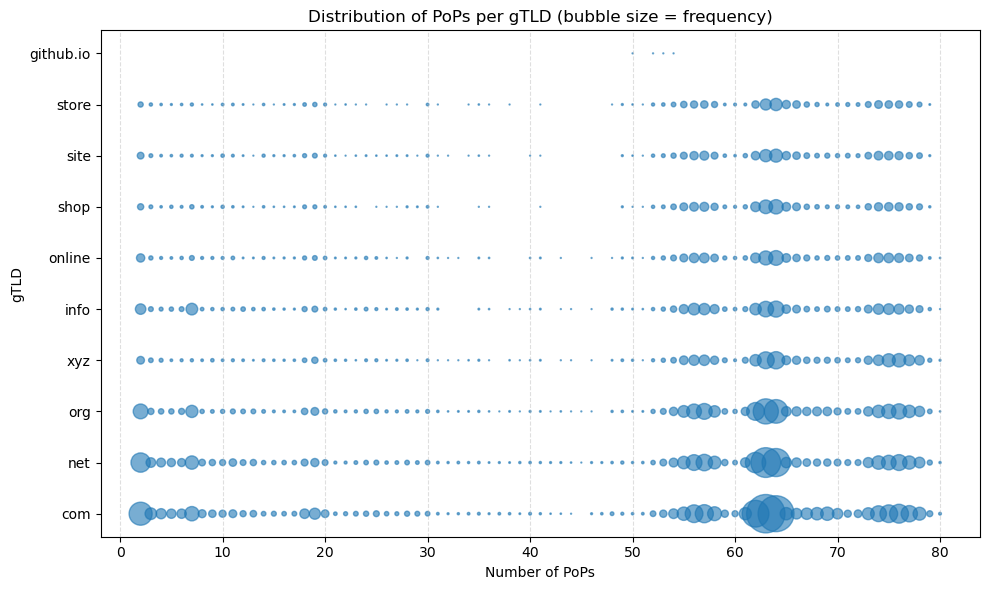

In [30]:
df = gtld_nr_pops_pdf.copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    df["nr_pops"],
    df["tld"],
    s=df["count"] / 2,     # scale bubble size (tune divisor)
    alpha=0.6
)

plt.xlabel("Number of PoPs")
plt.ylabel("gTLD")
plt.title("Distribution of PoPs per gTLD (bubble size = frequency)")
plt.grid(True, axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


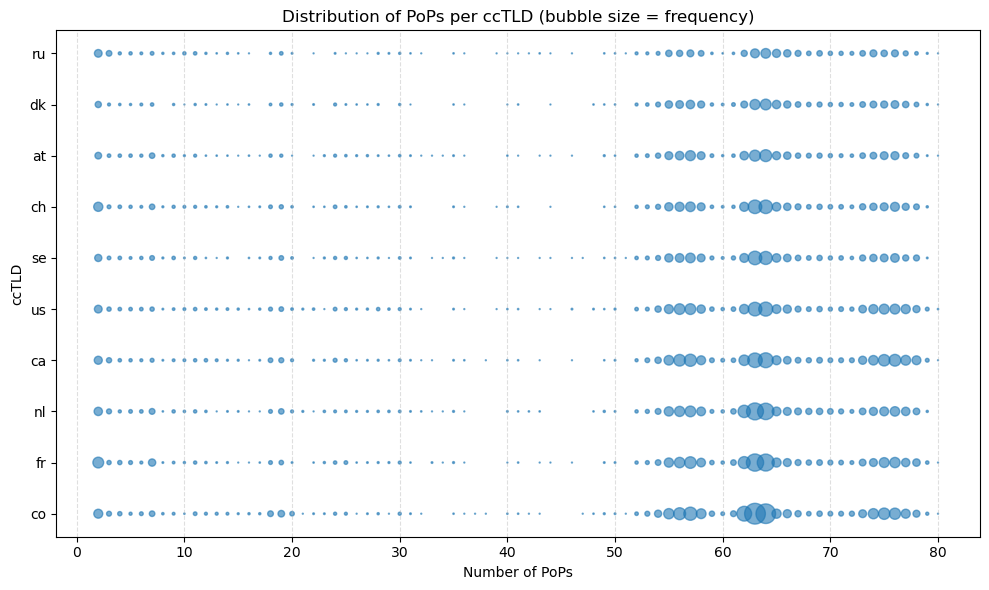

In [32]:
df = cctld_nr_pops_pdf.copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    df["nr_pops"],
    df["tld"],
    s=df["count"] / 2,     # scale bubble size (tune divisor)
    alpha=0.6
)

plt.xlabel("Number of PoPs")
plt.ylabel("ccTLD")
plt.title("Distribution of PoPs per ccTLD (bubble size = frequency)")
plt.grid(True, axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [12]:
len(plot_pdf_expanded)

404918

In [13]:
plot_pdf_expanded["tld"].nunique()

3170

## TLDs on anycast prefixes

In [47]:
tld_ip_cnt_pdf = oi_anycasted_df.withColumn(
    "tld", extract_tld(psf.col("hostname"))
).groupBy("tld").count().sort("count", ascending=False).toPandas()

In [49]:
cctld_country_pdf = pd.read_csv("cctld_alpha_3_mapping.csv")
display(cctld_country_pdf)

cctlds = list(set(cctld_country_pdf["cctld"].to_list()))

,cctld,alpha_3
0,ae,ARE
1,cr,CRI
2,my,MYS
3,ng,NGA
4,cu,CUB
...,...,...
319,xn--mgbbh1a,IND
320,xn--mgbc0a9azcg,MAR
321,xn--mgbgu82a,IND
322,gov,USA


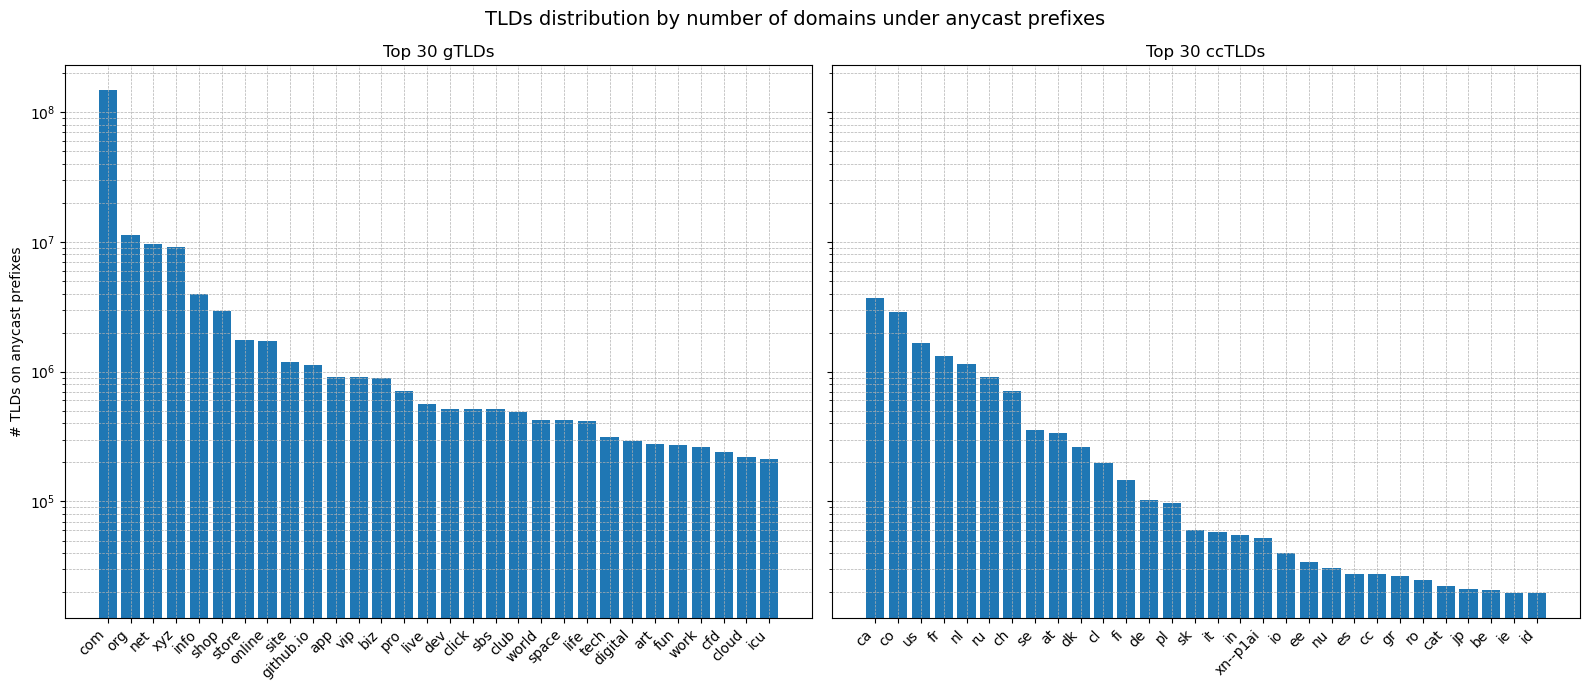

In [60]:
top_gtld_pdf = tld_ip_cnt_pdf[
    ~tld_ip_cnt_pdf["tld"].isin(cctlds)
].head(30).copy()

top_cctld_pdf = tld_ip_cnt_pdf[
    tld_ip_cnt_pdf["tld"].isin(cctlds)
].head(30).copy()


fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    sharey=True
)

# ---- gTLD plot ----
x1 = np.arange(len(top_gtld_pdf))
axes[0].bar(x1, top_gtld_pdf["count"])
axes[0].set_xticks(x1)
axes[0].set_xticklabels(top_gtld_pdf["tld"], rotation=45, ha="right")
axes[0].set_title("Top 30 gTLDs")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5)

# ---- ccTLD plot ----
x2 = np.arange(len(top_cctld_pdf))
axes[1].bar(x2, top_cctld_pdf["count"])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(top_cctld_pdf["tld"], rotation=45, ha="right")
axes[1].set_title("Top 30 ccTLDs")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)

# Shared labels
axes[0].set_ylabel("# TLDs on anycast prefixes")
fig.suptitle("TLDs distribution by number of domains under anycast prefixes", fontsize=14)

plt.tight_layout()
plt.show()


if False:
    ax = top_pdf.plot(
        kind="bar",
        x="tld",
        y="count",
        logy=True,
        legend=False
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(tld_counts["tld"], rotation=45, ha="right")
    
    ax.set_xlabel("")
    ax.set_ylabel("# TLD on a prefix")
    ax.set_title("Top 30 TLDs by number of domains under anycast prefixes")
    
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

In [53]:
print("# of anycasted ccTLDs -- not counting CT logs...")
print(len(set(tld_ip_cnt_pdf[tld_ip_cnt_pdf["tld"].isin(cctlds)]["tld"].to_list())))

print("# nr of unique ccTLD domains under anycast prefixes (IP granularity) -- not counting CT logs...")
print(tld_ip_cnt_pdf[tld_ip_cnt_pdf["tld"].isin(cctlds)]["count"].sum())

# of anycasted ccTLDs -- not counting CT logs...
250
# nr of unique ccTLD domains under anycast prefixes (IP granularity) -- not counting CT logs...
14788008


In [54]:
print("# of anycasted gTLDs")
print(
    len(set(tld_ip_cnt_pdf[
        ~tld_ip_cnt_pdf["tld"].isin(cctlds)
]["tld"].to_list()))
)

print("# nr of unique gTLD domains under anycast prefixes (IP granularity)")
print(
    tld_ip_cnt_pdf[
        ~tld_ip_cnt_pdf["tld"].isin(cctlds)
]["count"].sum()
)

# of anycasted gTLDs
2920
# nr of unique gTLD domains under anycast prefixes (IP granularity)
208423023


In [55]:
tld_ip_cnt_pdf["count"].sum()

223211031